<a href="https://colab.research.google.com/github/sumitkharayat/Machine-learning-work/blob/main/Customer%20Churn%20Prediction%3A%20Develop%20a%20model%20to%20predict%20customer%20churn%20in%20a%20subscription-based.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction: Develop a model to predict customer churn in a subscription-based business.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

In [ ]:
import os
os.listdir('/content/drive/MyDrive/Applied ML lab/EXPERIMENT 2,3,4')

['customer_churn_dataset.csv',
 'Housing_Price_Dataset_120_Records.csv',
 'stock_price_with_price_column.csv',
 'Untitled0.ipynb',
 'Experiment3.ipynb',
 'Experiment2.ipynb']

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Applied ML lab/EXPERIMENT 2,3,4/customer_churn_dataset.csv')

print(df.head())
print(df.info())

  CustomerID  Gender  Age  Tenure_Months SubscriptionType  MonthlyCharges  \
0   CUST1000    Male   49             54         Standard           99.33   
1   CUST1001  Female   56              8         Standard           12.01   
2   CUST1002    Male   66             27            Basic           57.62   
3   CUST1003    Male   69             27          Premium           97.08   
4   CUST1004    Male   49             34         Standard           54.69   

   TotalCharges PaymentMethod  SupportTickets ContractType  Churn  
0       4912.77   Net Banking               1     Two Year      0  
1        604.59    Debit Card               2     Two Year      0  
2       2019.39          Cash               4     Two Year      0  
3       4848.88   Credit Card               7     Two Year      0  
4       4334.26   Credit Card               9     One Year      1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column            N

In [ ]:
df.drop("CustomerID", axis=1, inplace=True)

converting target cause ML models need numerical values.

In [ ]:
# Convert 'TotalCharges' to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Display null counts after conversions
print("Null values after TotalCharges conversion:")
print(df.isnull().sum())

Null values after TotalCharges conversion:
Gender              0
Age                 0
Tenure_Months       0
SubscriptionType    0
MonthlyCharges      0
TotalCharges        0
PaymentMethod       0
SupportTickets      0
ContractType        0
Churn               0
dtype: int64


In [ ]:
df.dropna(inplace=True)

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df.drop("Churn", axis=1) #X → Input features
y = df["Churn"]              #y → Target (Churn)

In [ ]:
print("Shape:", df.shape)
print(df.head())

Shape: (200, 11)
  CustomerID  Gender  Age  Tenure_Months SubscriptionType  MonthlyCharges  \
0   CUST1000    Male   49             54         Standard           99.33   
1   CUST1001  Female   56              8         Standard           12.01   
2   CUST1002    Male   66             27            Basic           57.62   
3   CUST1003    Male   69             27          Premium           97.08   
4   CUST1004    Male   49             34         Standard           54.69   

   TotalCharges PaymentMethod  SupportTickets ContractType  Churn  
0       4912.77   Net Banking               1     Two Year    NaN  
1        604.59    Debit Card               2     Two Year    NaN  
2       2019.39          Cash               4     Two Year    NaN  
3       4848.88   Credit Card               7     Two Year    NaN  
4       4334.26   Credit Card               9     One Year    NaN  


In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (200, 14)
y shape: (200,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Feature scaling


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = LogisticRegression(max_iter=1000) #Regression model is used

In [ ]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

# Evaluation

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7


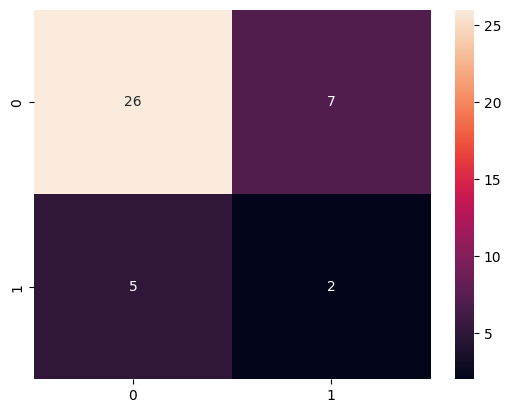

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.79      0.81        33
           1       0.22      0.29      0.25         7

    accuracy                           0.70        40
   macro avg       0.53      0.54      0.53        40
weighted avg       0.73      0.70      0.71        40



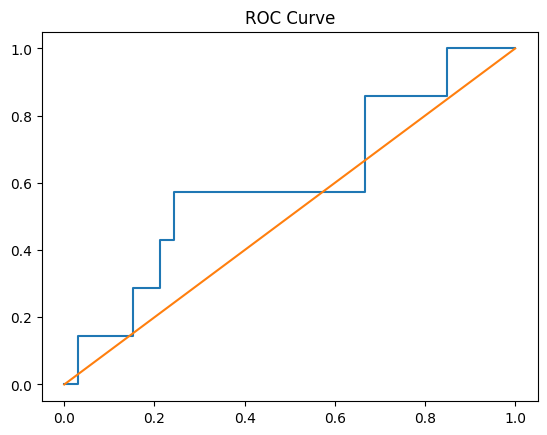

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.title("ROC Curve")
plt.show()